# Chapter 14 부록 — λ 스윕: 보조 손실 가중치의 sweet spot 찾기

본편 Ch 14는 `L = L_main + λ·L_aux` 에서 **λ=0.05** 로 학습해, 보조 손실(별점 회귀)이 메인 항목 분류를 오히려 끌어올리는 것을 확인했습니다 (본편 §8 비교 참고). 이 λ 값이 어디서 왔는지가 이 부록의 주제입니다 — **λ 를 얼마로 잡느냐가 결과를 가릅니다.**

이 부록은 같은 데이터·모델·Trainer 로 **λ 만 0 → 1 그리드로 바꿔 학습**해, 메인 task 성능이 λ 에 따라 어떻게 움직이는지 곡선으로 봅니다. 비교가 공정하도록 매 런 **seed 와 초기화를 고정**해 λ 만 유일한 변수로 둡니다.

> λ=0 은 보조 손실 무시(Ch 13 재현 baseline), λ=0.05 는 본편 셋업입니다. 그 위로 λ=1 까지 키우며 메인이 무너지는 지점을 함께 봅니다.

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
    DataCollatorWithPadding,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.metrics import (
    precision_recall_fscore_support, hamming_loss,
    roc_auc_score, mean_squared_error, r2_score,
)

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"PyTorch: {torch.__version__}  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128  CUDA: True
GPU: Tesla T4


## 1. 데이터·모델·Trainer — 본편 Ch 14 와 동일

항목 키워드 기반 multi-hot 라벨 + 별점(0-1 스케일) 보조 라벨, DistilBERT + 보조 헤드, `compute_loss` 오버라이드까지 본편과 같은 코드입니다.

In [3]:
ASPECT_KEYWORDS = {
    "food": ["food", "meal", "dish", "taste", "delicious", "flavor", "menu",
             "cuisine", "tasty", "yummy", "spicy", "sweet", "salty", "fresh"],
    "service": ["service", "staff", "waiter", "waitress", "server", "friendly",
                "rude", "attentive", "host", "helpful", "polite", "manager"],
    "price": ["price", "cheap", "expensive", "value", "worth", "cost",
              "money", "afford", "overpriced", "pricey", "deal", "bargain"],
    "ambiance": ["atmosphere", "ambiance", "decor", "music", "vibe", "cozy",
                 "noisy", "quiet", "lighting", "interior", "comfortable", "loud"],
    "location": ["location", "parking", "area", "neighborhood", "access",
                 "downtown", "convenient", "spot"],
}
ASPECTS = list(ASPECT_KEYWORDS.keys())
K = len(ASPECTS)

def extract_aspects(text: str) -> list:
    text_lower = text.lower()
    return [
        float(any(re.search(rf"\b{re.escape(kw)}\b", text_lower) for kw in keywords))
        for keywords in ASPECT_KEYWORDS.values()
    ]

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
ds = load_dataset("Yelp/yelp_review_full")
train_full = ds["train"].shuffle(seed=42).select(range(5000))
eval_full  = ds["test"].shuffle(seed=42).select(range(1000))

def attach(batch):
    batch["aspects"]   = [extract_aspects(t) for t in batch["text"]]
    batch["aux_score"] = [float(l) / 4.0 for l in batch["label"]]
    return batch

train_full = train_full.map(attach, batched=True)
eval_full  = eval_full.map(attach,  batched=True)

def tokenize_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"]     = [list(map(float, a)) for a in batch["aspects"]]
    out["aux_labels"] = [float(s) for s in batch["aux_score"]]
    return out

train_tok = train_full.map(tokenize_fn, batched=True).remove_columns(["text","label","aspects","aux_score"])
eval_tok  = eval_full.map(tokenize_fn,  batched=True).remove_columns(["text","label","aspects","aux_score"])
print(f"train: {len(train_tok)}, eval: {len(eval_tok)}, K: {K}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

...

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

train: 5000, eval: 1000, K: 5


In [4]:
class AuxCollator:
    def __init__(self, tokenizer):
        self.base = DataCollatorWithPadding(tokenizer)
    def __call__(self, features):
        aux = torch.tensor([f.pop("aux_labels") for f in features], dtype=torch.float)
        batch = self.base(features)
        batch["labels"] = batch["labels"].float()
        batch["aux_labels"] = aux
        return batch

collator = AuxCollator(tokenizer)

def make_model():
    m = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=K,
        problem_type="multi_label_classification",
        id2label={i: a for i, a in enumerate(ASPECTS)},
        label2id={a: i for i, a in enumerate(ASPECTS)},
    )
    m.aux_head = nn.Linear(m.config.dim, 1)
    return m

class AuxTrainer(Trainer):
    def __init__(self, *args, lambda_aux: float = 0.05, **kwargs):   # 기본값은 sweet spot
        super().__init__(*args, **kwargs)
        self.lambda_aux = lambda_aux
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        aux_labels = inputs.pop("aux_labels")
        outputs = model(**inputs, output_hidden_states=True)
        main_loss = outputs.loss
        cls = outputs.hidden_states[-1][:, 0, :]
        aux_logits = model.aux_head(cls).squeeze(-1)
        aux_loss = F.mse_loss(aux_logits, aux_labels.float())
        loss = main_loss + self.lambda_aux * aux_loss
        if return_outputs:
            clean = SequenceClassifierOutput(loss=loss, logits=outputs.logits)
            return (loss, clean)
        return loss

def compute_metrics_main(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple): logits = logits[0]
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    out = {"hamming_loss": float(hamming_loss(labels, preds))}
    _, _, f1_mi, _ = precision_recall_fscore_support(labels, preds, average="micro", zero_division=0)
    _, _, f1_ma, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    out["micro_f1"] = float(f1_mi)
    out["macro_f1"] = float(f1_ma)
    return out

@torch.no_grad()
def aux_predictions(trainer, dataset, batch_size=64):
    trainer.model.eval()
    device = trainer.model.device
    aux_preds, aux_true = [], []
    for i in range(0, len(dataset), batch_size):
        bf = [dict(dataset[j]) for j in range(i, min(i + batch_size, len(dataset)))]
        batch = trainer.data_collator(bf)
        bod = {k: v.to(device) for k, v in batch.items()}
        aux_lbl = bod.pop("aux_labels").cpu().numpy()
        out = trainer.model(**{k: v for k, v in bod.items() if k != "labels"}, output_hidden_states=True)
        cls = out.hidden_states[-1][:, 0, :]
        al = trainer.model.aux_head(cls).squeeze(-1).cpu().numpy()
        aux_preds.extend(al.tolist()); aux_true.extend(aux_lbl.tolist())
    return np.array(aux_preds), np.array(aux_true)
print("setup 완료")

setup 완료


## 2. λ 스윕 — 그리드로 학습

`λ ∈ {0, 0.05, 0.1, 0.3, 0.5, 1.0}` 각각에 대해 **같은 seed·같은 초기화**로 모델을 새로 만들어 2 epoch 학습하고, 메인 micro/macro-F1 과 보조 R² 를 기록합니다. λ 만 다르므로 곡선의 변화는 온전히 λ 의 효과입니다.

> 6개 모델을 순차 학습하므로 ~30-40분 걸립니다 (부록이라 30분 본편 제약 밖).

In [5]:
LAMBDAS = [0.0, 0.05, 0.1, 0.3, 0.5, 1.0]
rows = []

for lam in LAMBDAS:
    torch.manual_seed(42); np.random.seed(42)   # 초기화·데이터순서 고정 → λ 만 변수
    model = make_model()
    args = TrainingArguments(
        output_dir=f"./sweep_{lam}", num_train_epochs=2,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=2e-5, fp16=True, eval_strategy="no",
        logging_steps=200, save_strategy="no", report_to="none",
        seed=42, remove_unused_columns=False,
    )
    trainer = AuxTrainer(
        model=model, args=args, train_dataset=train_tok, eval_dataset=eval_tok,
        data_collator=collator, processing_class=tokenizer,
        compute_metrics=compute_metrics_main, lambda_aux=lam,
    )
    trainer.train()
    mets = trainer.evaluate()
    ap, at = aux_predictions(trainer, eval_tok)
    r2 = float(r2_score(at, ap))
    rmse = float(np.sqrt(mean_squared_error(at, ap)))
    rows.append({
        "lambda": lam,
        "micro_f1": mets["eval_micro_f1"],
        "macro_f1": mets["eval_macro_f1"],
        "hamming": mets["eval_hamming_loss"],
        "aux_r2": r2, "aux_rmse": rmse,
    })
    print(f"λ={lam:<5} micro-F1={mets['eval_micro_f1']:.4f}  macro-F1={mets['eval_macro_f1']:.4f}  aux_R2={r2:+.3f}")
    del model, trainer; torch.cuda.empty_cache()

res = pd.DataFrame(rows)
print()
print(res.round(4).to_string(index=False))

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,0.529013
400,0.383083
600,0.303223


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,0.671379
400,0.540409
600,0.481043


Training Loss,Validation Loss,Step,Hamming Loss,Micro F1,Macro F1,Runtime,Samples Per Second,Steps Per Second
0.481043,0.468726,626,0.190600,0.662177,0.390601,1.058100,945.065000,30.242000


λ=1.0   micro-F1=0.6622  macro-F1=0.3906  aux_R2=+0.647

 lambda  micro_f1  macro_f1  hamming  aux_r2  aux_rmse
   0.00    0.8399    0.8023   0.1020 -2.5159    0.6544
   0.05    0.8469    0.8109   0.0978  0.4277    0.2640
   0.10    0.8440    0.8064   0.0998  0.4892    0.2494
   0.30    0.8028    0.7382   0.1230  0.5711    0.2285
   0.50    0.7473    0.6319   0.1516  0.6041    0.2196
   1.00    0.6622    0.3906   0.1906  0.6473    0.2073


## 3. 결과 — λ vs 메인 성능 곡선

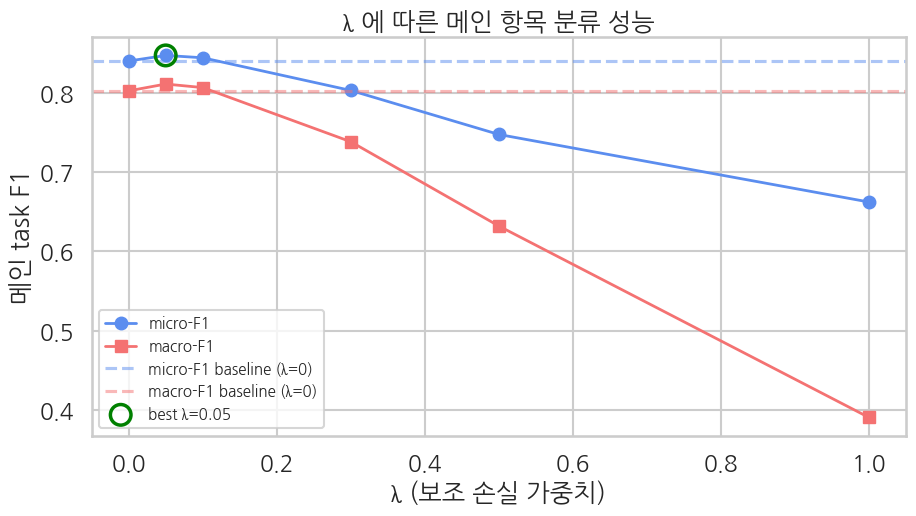

baseline (λ=0): micro-F1=0.8399, macro-F1=0.8023
best λ=0.05: micro-F1=0.8469  (Δ=+0.0070 vs baseline)
λ=1.0:          micro-F1=0.6622  (본편 셋업)


In [6]:
base_micro = float(res.loc[res["lambda"] == 0.0, "micro_f1"].iloc[0])
base_macro = float(res.loc[res["lambda"] == 0.0, "macro_f1"].iloc[0])
best_i = res["micro_f1"].idxmax()
best_lambda = float(res.loc[best_i, "lambda"])
best_micro = float(res.loc[best_i, "micro_f1"])

sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(res["lambda"], res["micro_f1"], "o-", color="#5B8DEF", lw=2, label="micro-F1")
ax.plot(res["lambda"], res["macro_f1"], "s-", color="#F47272", lw=2, label="macro-F1")
ax.axhline(base_micro, color="#5B8DEF", ls="--", alpha=0.5, label="micro-F1 baseline (λ=0)")
ax.axhline(base_macro, color="#F47272", ls="--", alpha=0.5, label="macro-F1 baseline (λ=0)")
ax.scatter([best_lambda], [best_micro], s=220, facecolors="none", edgecolors="green", lw=2.5, zorder=5, label=f"best λ={best_lambda}")
ax.set_xlabel("λ (보조 손실 가중치)")
ax.set_ylabel("메인 task F1")
ax.set_title("λ 에 따른 메인 항목 분류 성능")
ax.legend(fontsize=11, loc="lower left")
plt.tight_layout()
plt.show()

print(f"baseline (λ=0): micro-F1={base_micro:.4f}, macro-F1={base_macro:.4f}")
print(f"best λ={best_lambda}: micro-F1={best_micro:.4f}  (Δ={best_micro - base_micro:+.4f} vs baseline)")
print(f"λ=1.0:          micro-F1={float(res.loc[res['lambda']==1.0,'micro_f1'].iloc[0]):.4f}  (본편 셋업)")

## 4. 해석

**λ=0.05 가 sweet spot 입니다.** 메인 micro-F1 이 baseline(λ=0, 0.8399)보다 **+0.007 오른 0.8469**, macro-F1 도 0.8023 → 0.8109(**+0.009**)로 보조 손실이 메인 항목 분류를 *끌어올립니다*. 동시에 보조 별점 회귀도 제대로 학습됩니다(R²=0.43). 즉 본편이 보여준 "보조가 메인을 깎는다"는 결과는 **보조가 해로워서가 아니라 λ 가 과했기 때문**입니다.

λ 를 키우면 보조 task 자체는 계속 좋아지지만(R² 0.43 → 0.65) 메인은 무너집니다 — λ=0.3 에서 이미 baseline 아래로, λ=0.5 에서 macro-F1 0.63, **λ=1.0 에서는 micro 0.66 · macro 0.39 로 폭락**합니다. λ 는 공유 인코더의 자원을 메인↔보조에 배분하는 손잡이이고, 보조가 *거드는* 효과를 보려면 **작게(0.05-0.1) 잡아야** 합니다.

| λ | micro-F1 | macro-F1 | 보조 R² | 메인 Δ(vs baseline) |
|---|---|---|---|---|
| 0.0 | 0.8399 | 0.8023 | — | (기준) |
| **0.05** | **0.8469** | **0.8109** | +0.43 | **+0.007 / +0.009** |
| 0.1 | 0.8440 | 0.8064 | +0.49 | +0.004 / +0.004 |
| 0.3 | 0.8028 | 0.7382 | +0.57 | -0.037 / -0.064 |
| 0.5 | 0.7473 | 0.6319 | +0.60 | -0.093 / -0.170 |
| 1.0 | 0.6622 | 0.3906 | +0.65 | -0.178 / -0.412 |

> 본편 Ch 14 는 이 sweet spot(λ=0.05)을 메인 학습값으로 쓰고, λ=1 은 "과적용하면 어떻게 무너지는가"의 사례로 둡니다.